# IKE Rate-of-Change by ET Phase and Shear Category (North Atlantic vs. West Pacific)

2-panel box plots (one per basin) of the 6-hour rate of change of Vmax / IKE / Pmin / R34,
split by storm phase (Early Tropical vs. Pre-ET, <48hr from extratropical transition) and
deep-layer shear category (Low/Mod/High), for storms with and without land interaction --
8 figures total (4 variables × 2 land-interaction filters).

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["SHIPS_PATH"] = "/data/jacob.carstens/SHIPS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.shear_rate_of_change import (
    load_master_dataframe_shear_composite,
    add_shear_categories,
    compute_rate_of_change_plot_df,
)


## Data extraction

Only North Atlantic and West Pacific, matching the source script.

In [3]:
BASINS = ["North Atlantic", "West Pacific"]

master_df = load_master_dataframe_shear_composite(
    basins=BASINS,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    ships_file_map=config.SHIPS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    ships_base_path=config.SHIPS_BASE_PATH,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH/SHIPS_PATH.")

master_df = add_shear_categories(master_df)
print(f"{len(master_df)} qualifying timesteps after shear categorization.")


--- Loading Data (2004-2024) ---

--- Loading Data for North Atlantic ---
Processing 380 storms in North Atlantic...
        - Filtered out 2 crossover/external storms based on official genesis basin label.

--- Loading Data for West Pacific ---
Processing 622 storms in West Pacific...
        - Filtered out 16 crossover/external storms based on official genesis basin label.
14171 qualifying timesteps after shear categorization.


## Variable configs

`col_name` is the actual DataFrame column; `y_limits` bound each box plot's y-axis.

In [4]:
VARIABLES = {
    "Vmax": ["vmax_kts",     "kts", 1, [-30, 30]],
    "IKE":  ["total_ike_tj", "TJ",  1, [-20, 20]],
    "Pmin": ["pmin_mb",      "mb",  1, [-40, 40]],
    "R34":  ["r34_nm",       "nm",  1, [-50, 50]],
}


## Plotting function

In [5]:
def plot_rate_of_change_boxplots_shear_split(plot_df, diff_col_name, var_name, units, land_filter_text, y_limits):
    diff_hours = 6  # diff_periods=1 for every variable here
    print(f"\n--- Generating 2-Panel Box Plots ({var_name}, {diff_hours}hr Diff, Split by Shear) ---")

    phase_order_plot = list(plot_df["phase"].cat.categories)
    shear_order = list(plot_df["shear_cat"].cat.categories)
    warm_palette = ["peachpuff", "coral", "firebrick"]

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11, 13), sharex=True)
    basins_to_plot = ["North Atlantic", "West Pacific"]

    for i, basin_name in enumerate(basins_to_plot):
        ax = axes[i]
        basin_data = plot_df[plot_df["basin"] == basin_name]

        sns.boxplot(
            x="phase", y=diff_col_name, hue="shear_cat", data=basin_data, ax=ax,
            order=phase_order_plot, hue_order=shear_order, palette=warm_palette,
            showfliers=False, width=0.75,
        )

        if y_limits:
            ax.set_ylim(y_limits[0], y_limits[1])

        ax.axhline(0, color="black", linestyle="--", lw=1.5)
        ax.set_ylabel(f"{diff_hours}hr $\\Delta$ {var_name} ({units})", fontsize=14, fontweight="bold")
        ax.set_title(f"{basin_name}", fontsize=16, weight="bold", pad=10)
        ax.grid(True, axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="y", labelsize=14)

        if i == 0:
            ax.legend(title="Shear Magnitude (m/s)", title_fontsize=16, fontsize=12, loc="upper left")
        elif ax.get_legend() is not None:
            ax.get_legend().remove()

        if i == 1:
            ax.set_xlabel("Storm Phase", fontsize=14, fontweight="bold")
            ax.tick_params(axis="x", labelsize=12)
        else:
            ax.set_xlabel("")

    fig.suptitle(f"Rate of {var_name} Change by Phase & Shear{land_filter_text}", fontsize=18, weight="bold")
    fig.tight_layout()
    fig.subplots_adjust(top=0.92, hspace=0.1)

    os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
    filename = f"COMPOSITE_SHEAR_MS_{var_name.lower()}_rate_of_change_{land_filter_text.replace(' ', '_').replace(',', '')}.png"
    plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()
    print(f"    - Plot saved: {filename}")


## Generate all 8 figures

For each of the two land-interaction scenarios (storms with any landfall excluded
entirely, vs. all storms), and each of the four variables.


--- Starting Analysis for: No Land Interaction ---

--- Generating 2-Panel Box Plots (Vmax, 6hr Diff, Split by Shear) ---


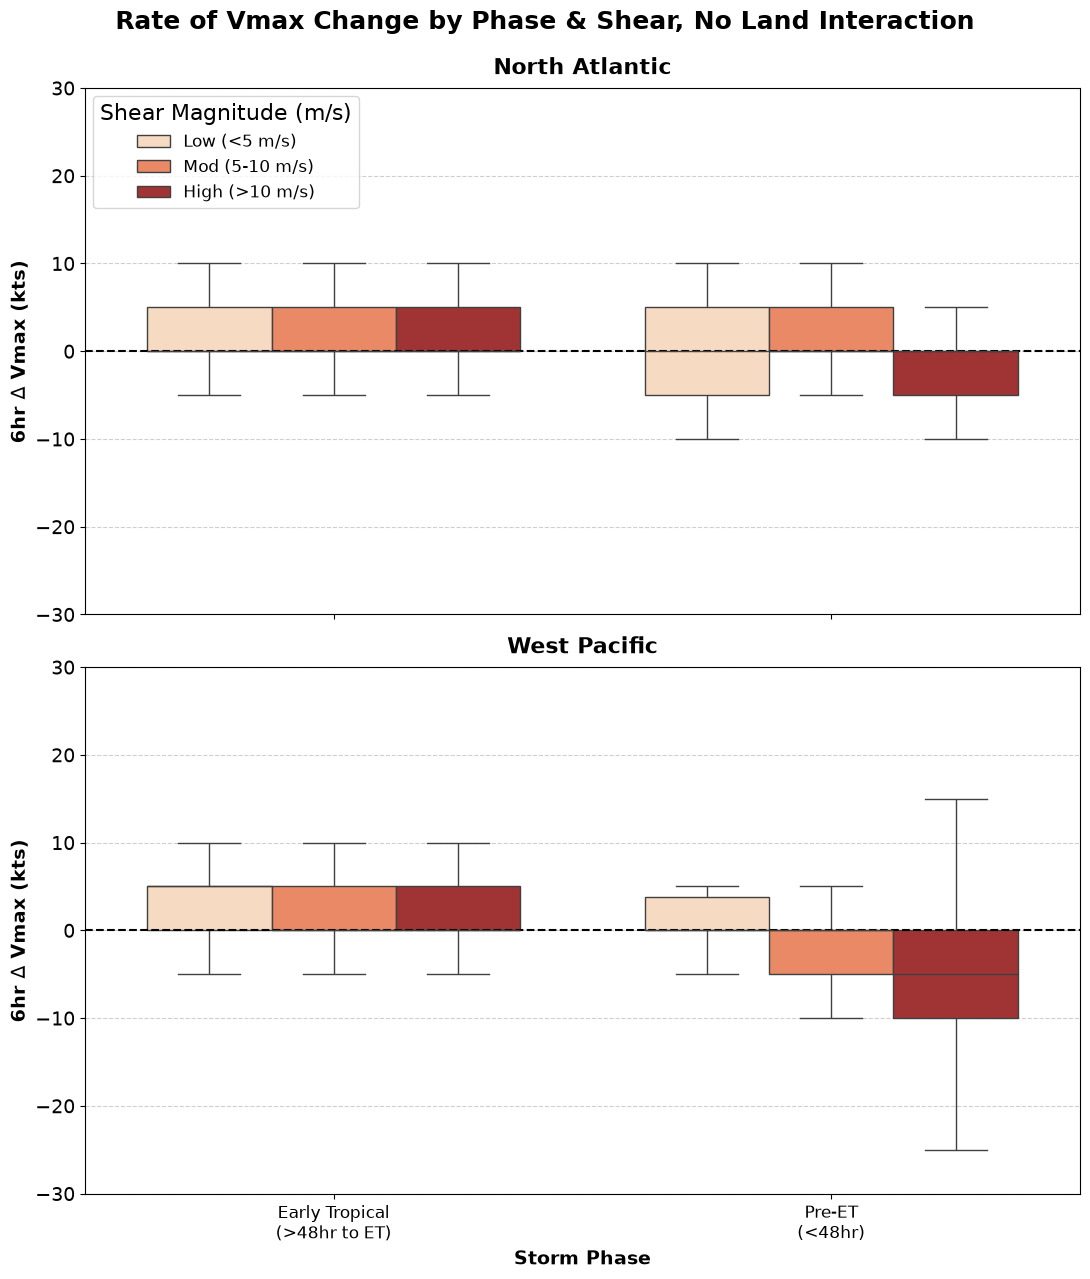

    - Plot saved: COMPOSITE_SHEAR_MS_vmax_rate_of_change__No_Land_Interaction.png

--- Generating 2-Panel Box Plots (IKE, 6hr Diff, Split by Shear) ---


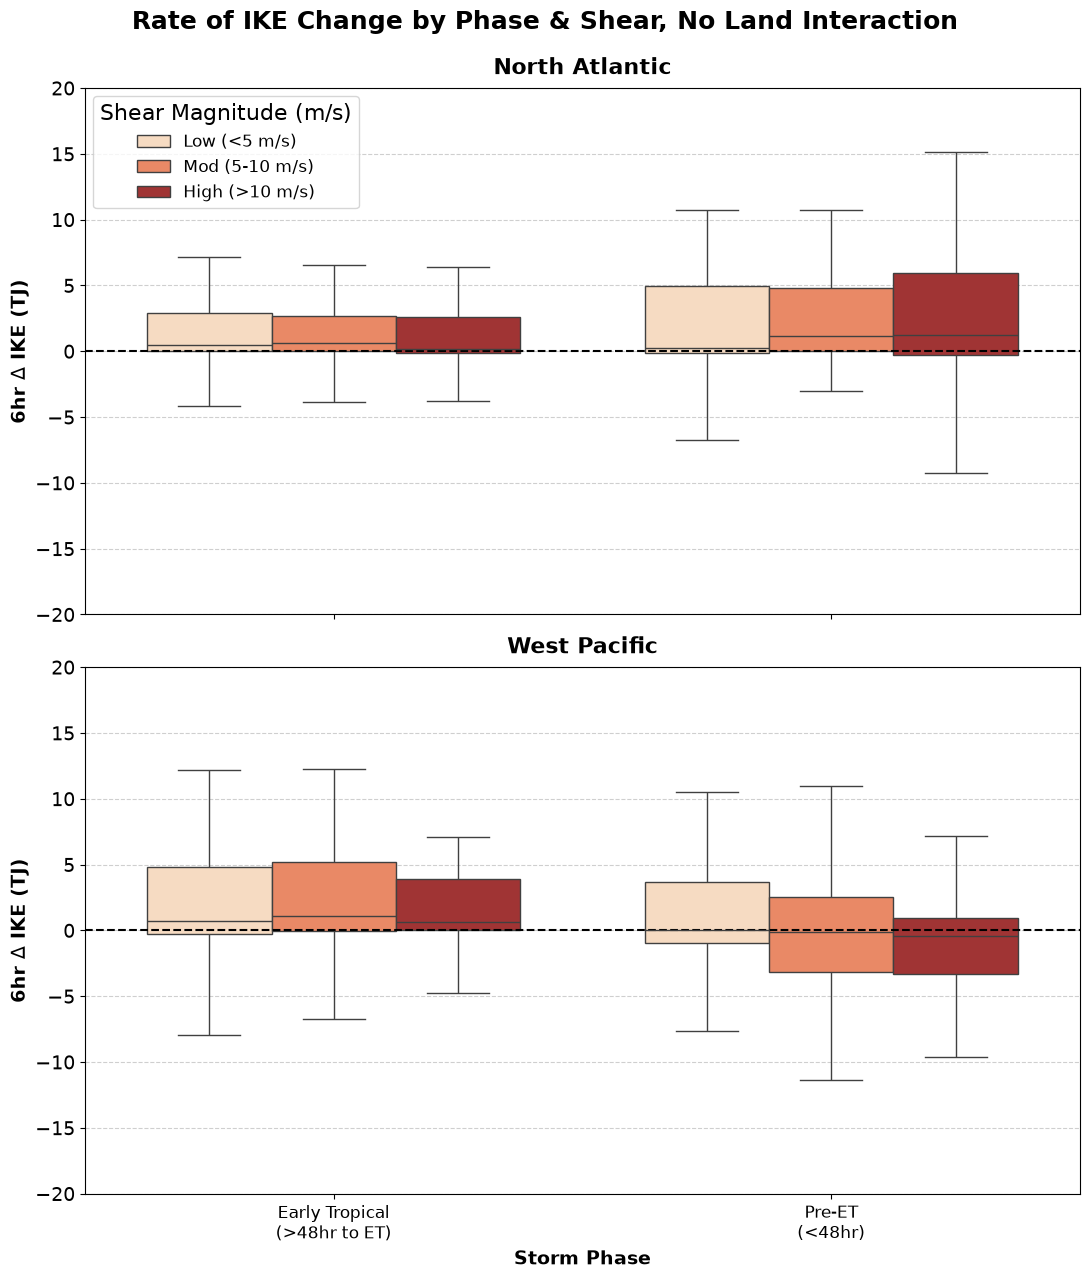

    - Plot saved: COMPOSITE_SHEAR_MS_ike_rate_of_change__No_Land_Interaction.png

--- Generating 2-Panel Box Plots (Pmin, 6hr Diff, Split by Shear) ---


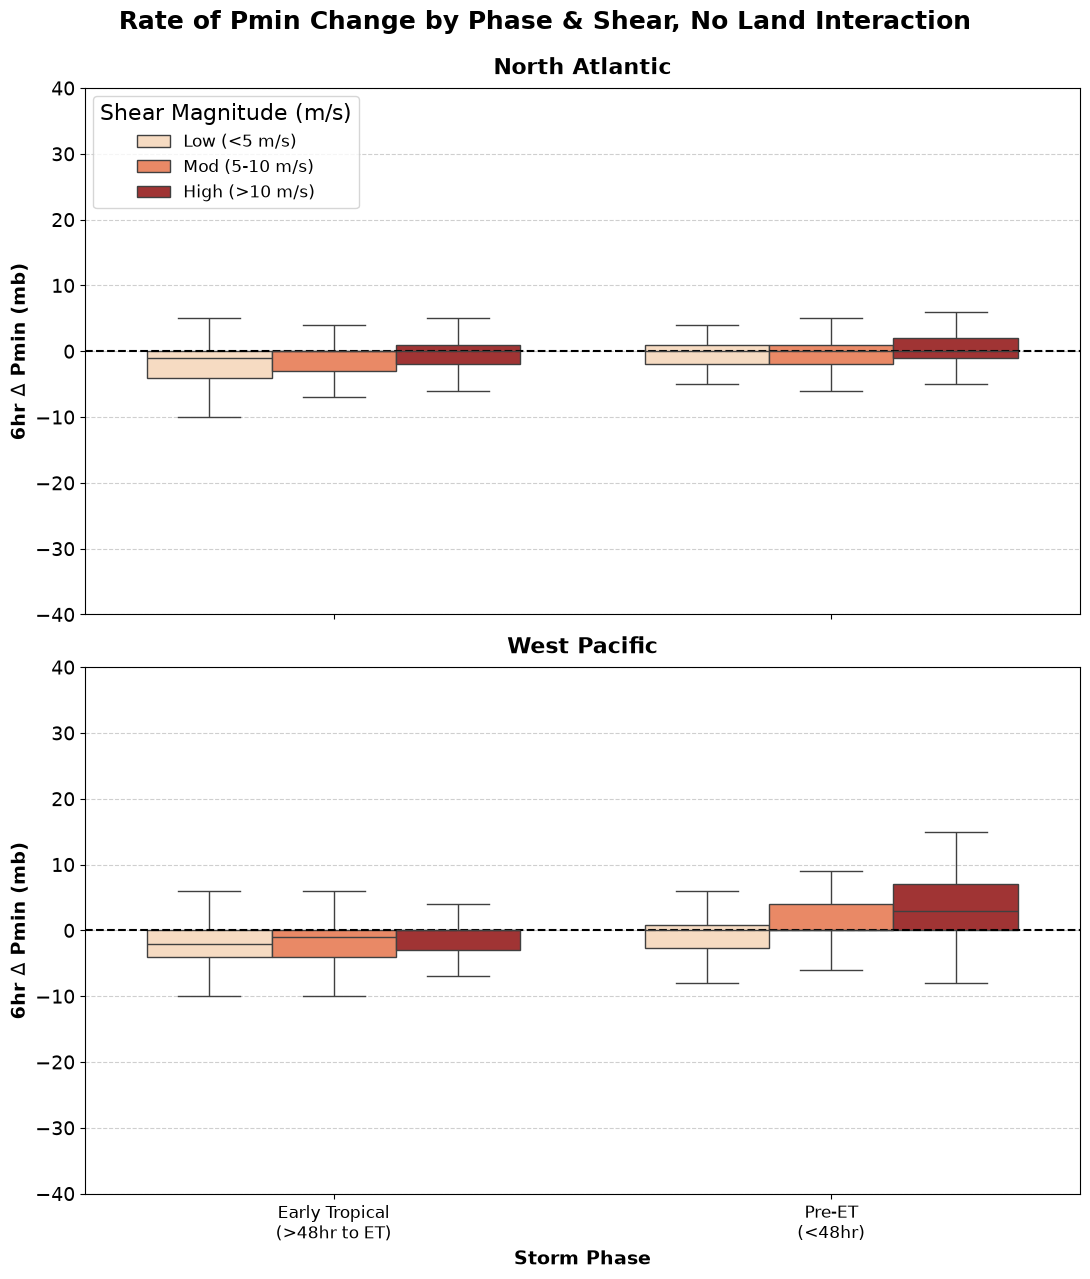

    - Plot saved: COMPOSITE_SHEAR_MS_pmin_rate_of_change__No_Land_Interaction.png

--- Generating 2-Panel Box Plots (R34, 6hr Diff, Split by Shear) ---


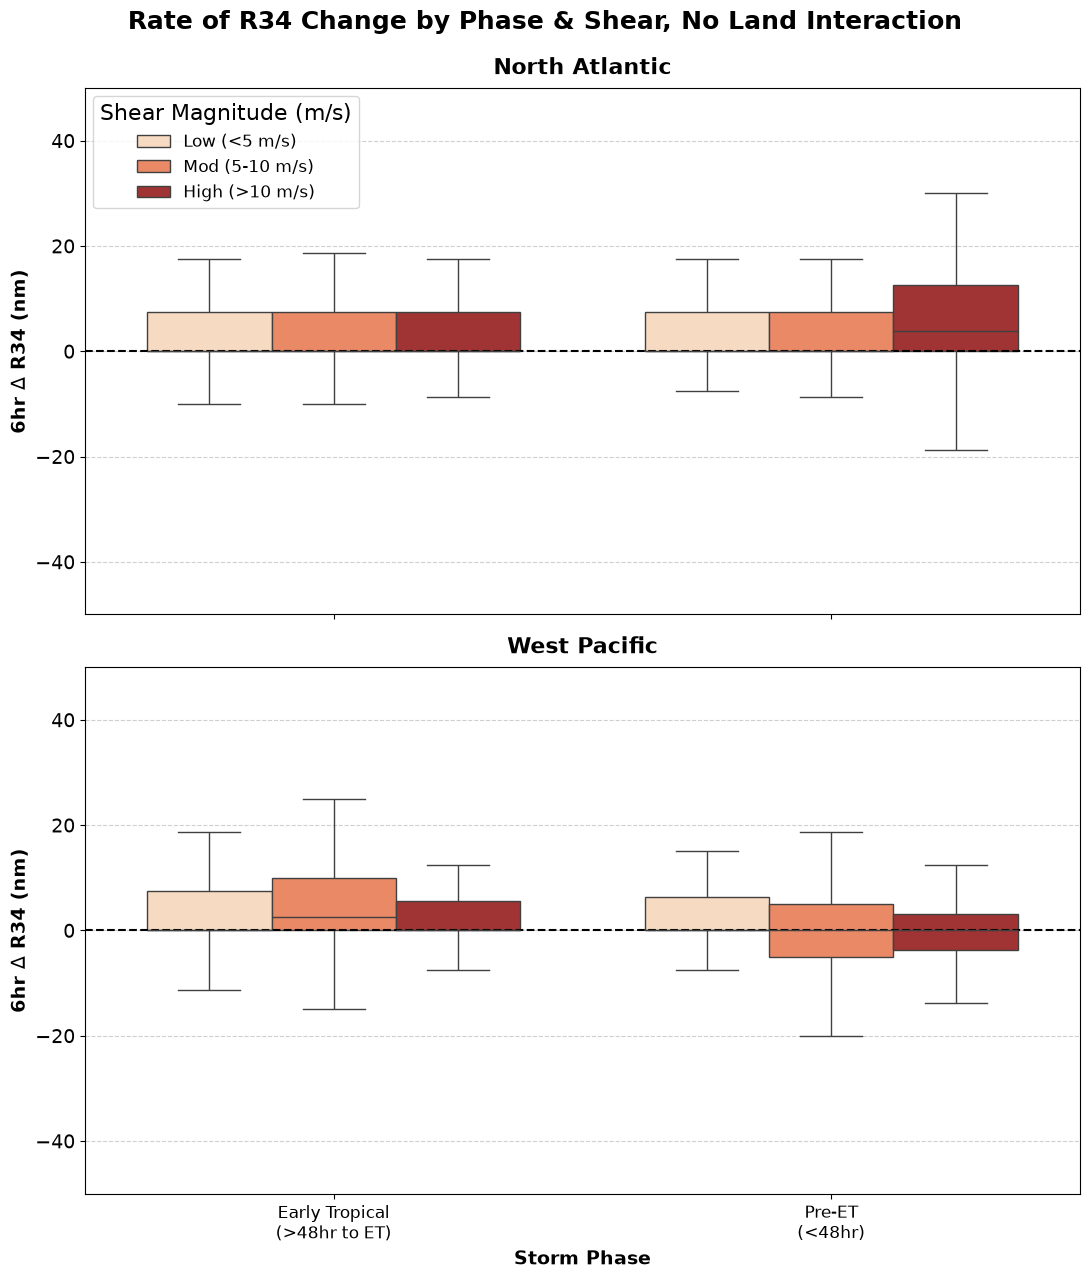

    - Plot saved: COMPOSITE_SHEAR_MS_r34_rate_of_change__No_Land_Interaction.png

--- Starting Analysis for: All Storms ---

--- Generating 2-Panel Box Plots (Vmax, 6hr Diff, Split by Shear) ---


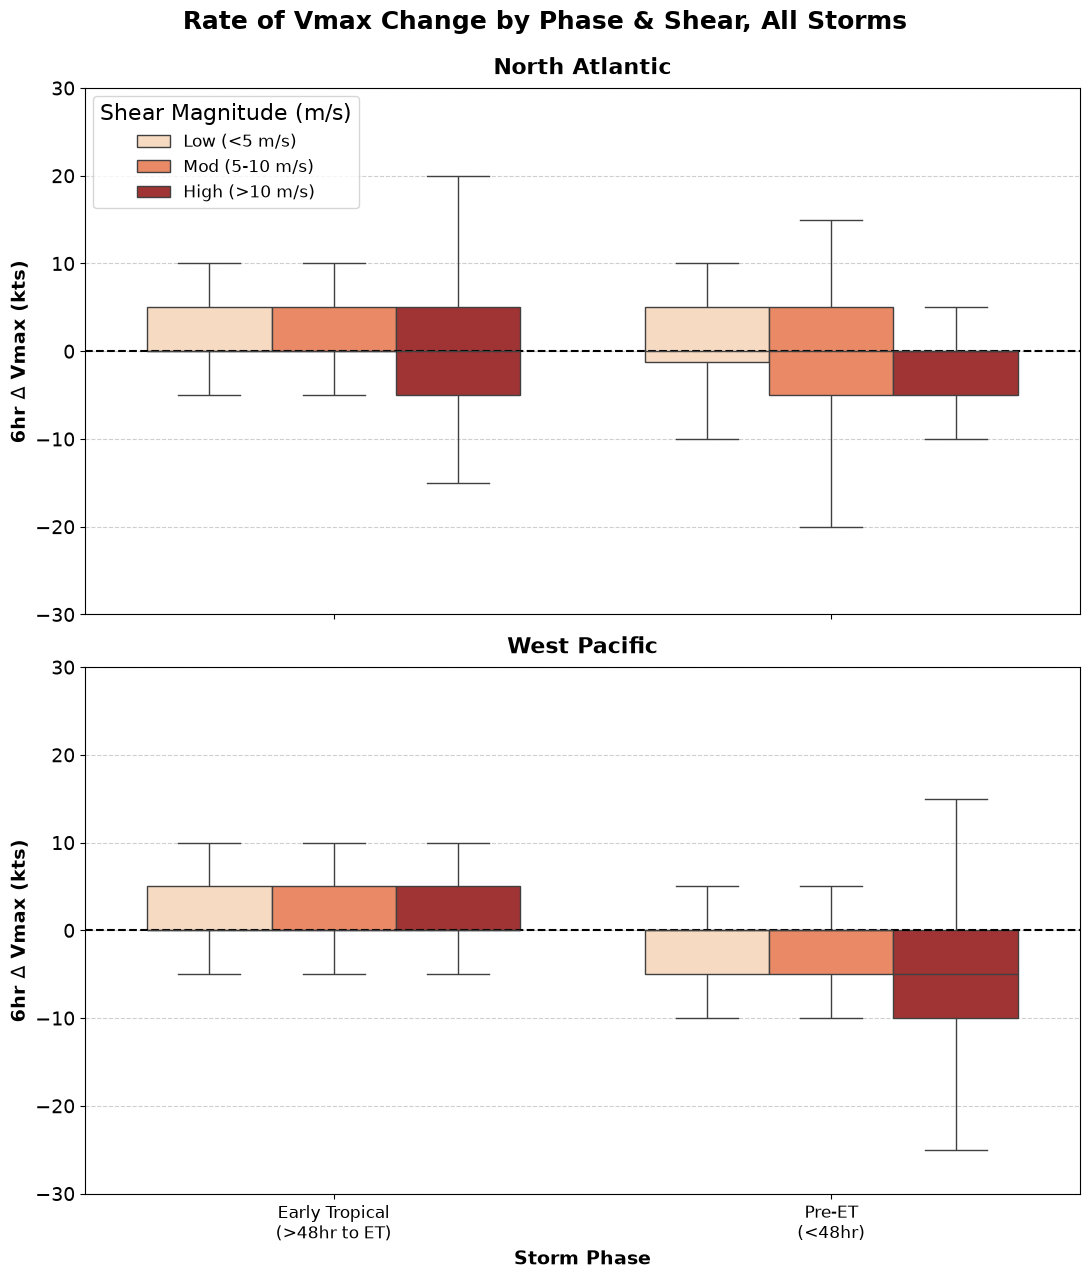

    - Plot saved: COMPOSITE_SHEAR_MS_vmax_rate_of_change__All_Storms.png

--- Generating 2-Panel Box Plots (IKE, 6hr Diff, Split by Shear) ---


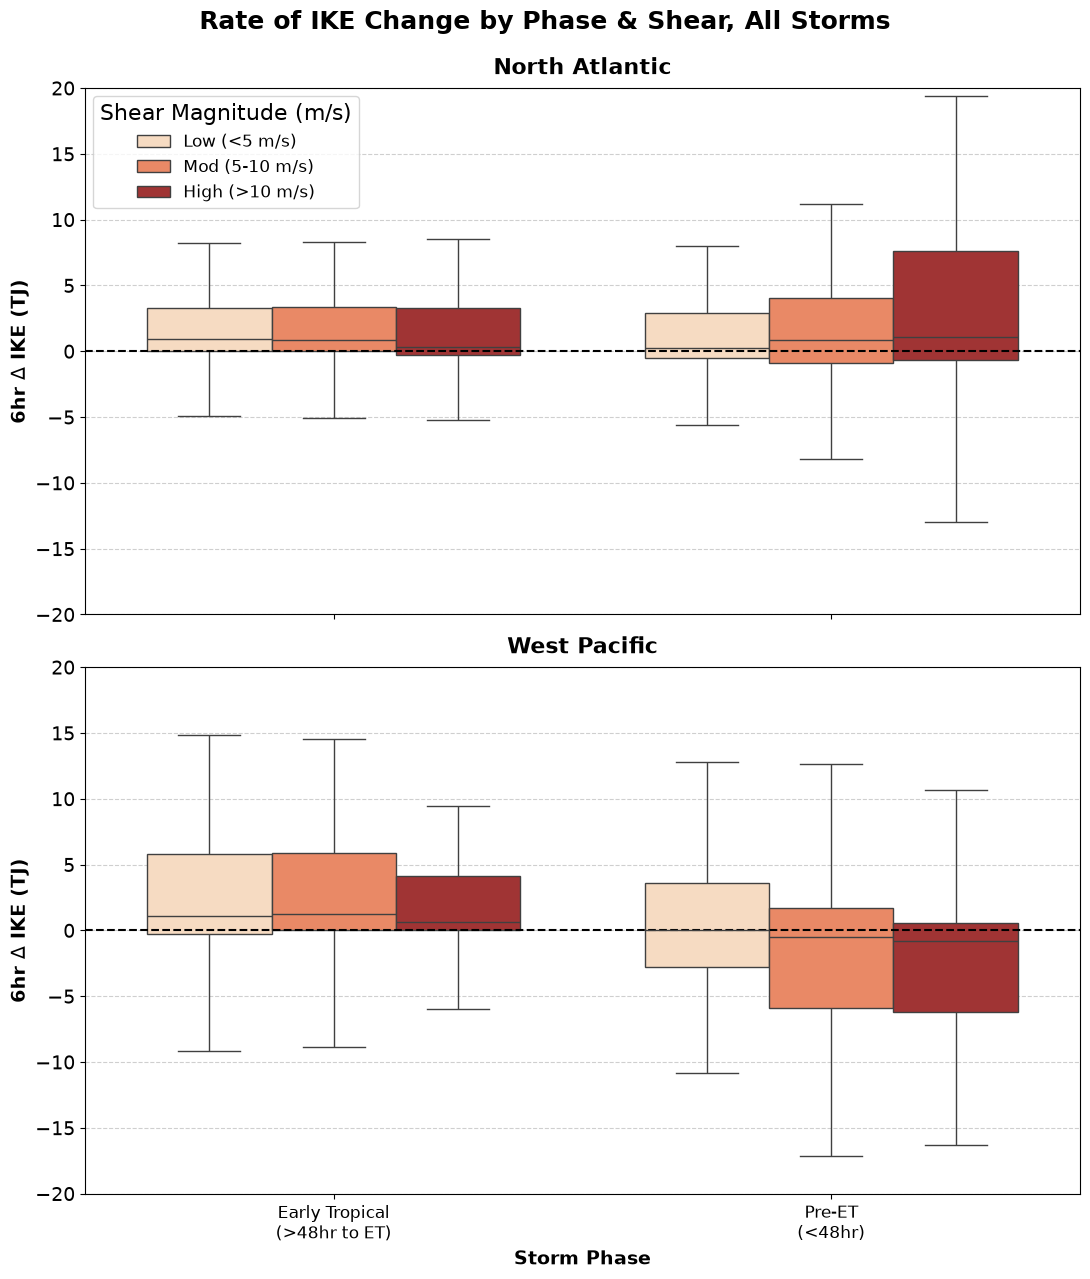

    - Plot saved: COMPOSITE_SHEAR_MS_ike_rate_of_change__All_Storms.png

--- Generating 2-Panel Box Plots (Pmin, 6hr Diff, Split by Shear) ---


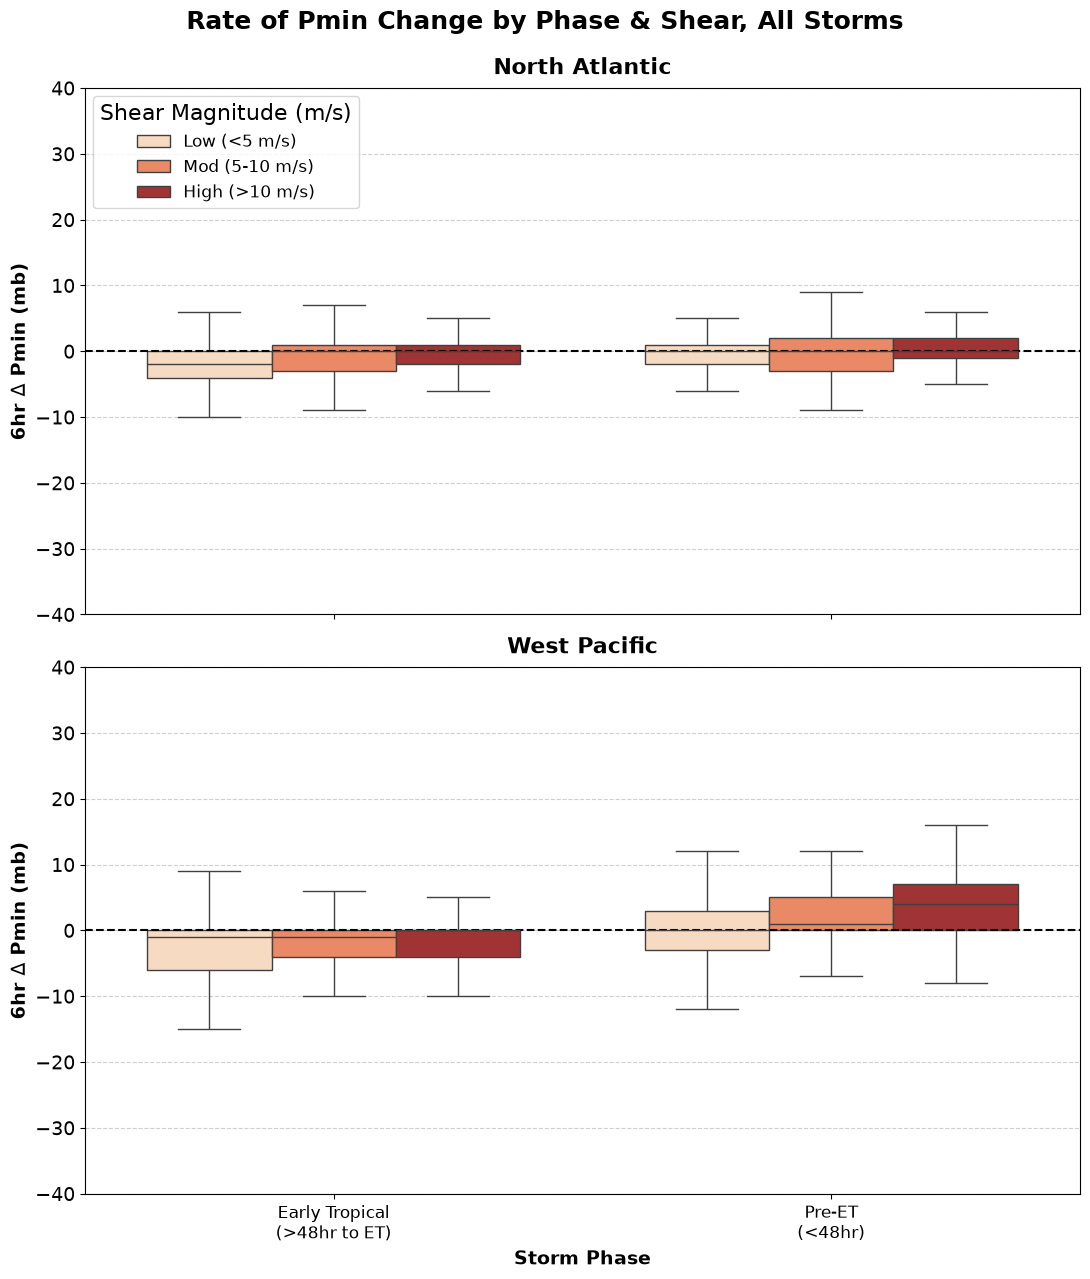

    - Plot saved: COMPOSITE_SHEAR_MS_pmin_rate_of_change__All_Storms.png

--- Generating 2-Panel Box Plots (R34, 6hr Diff, Split by Shear) ---


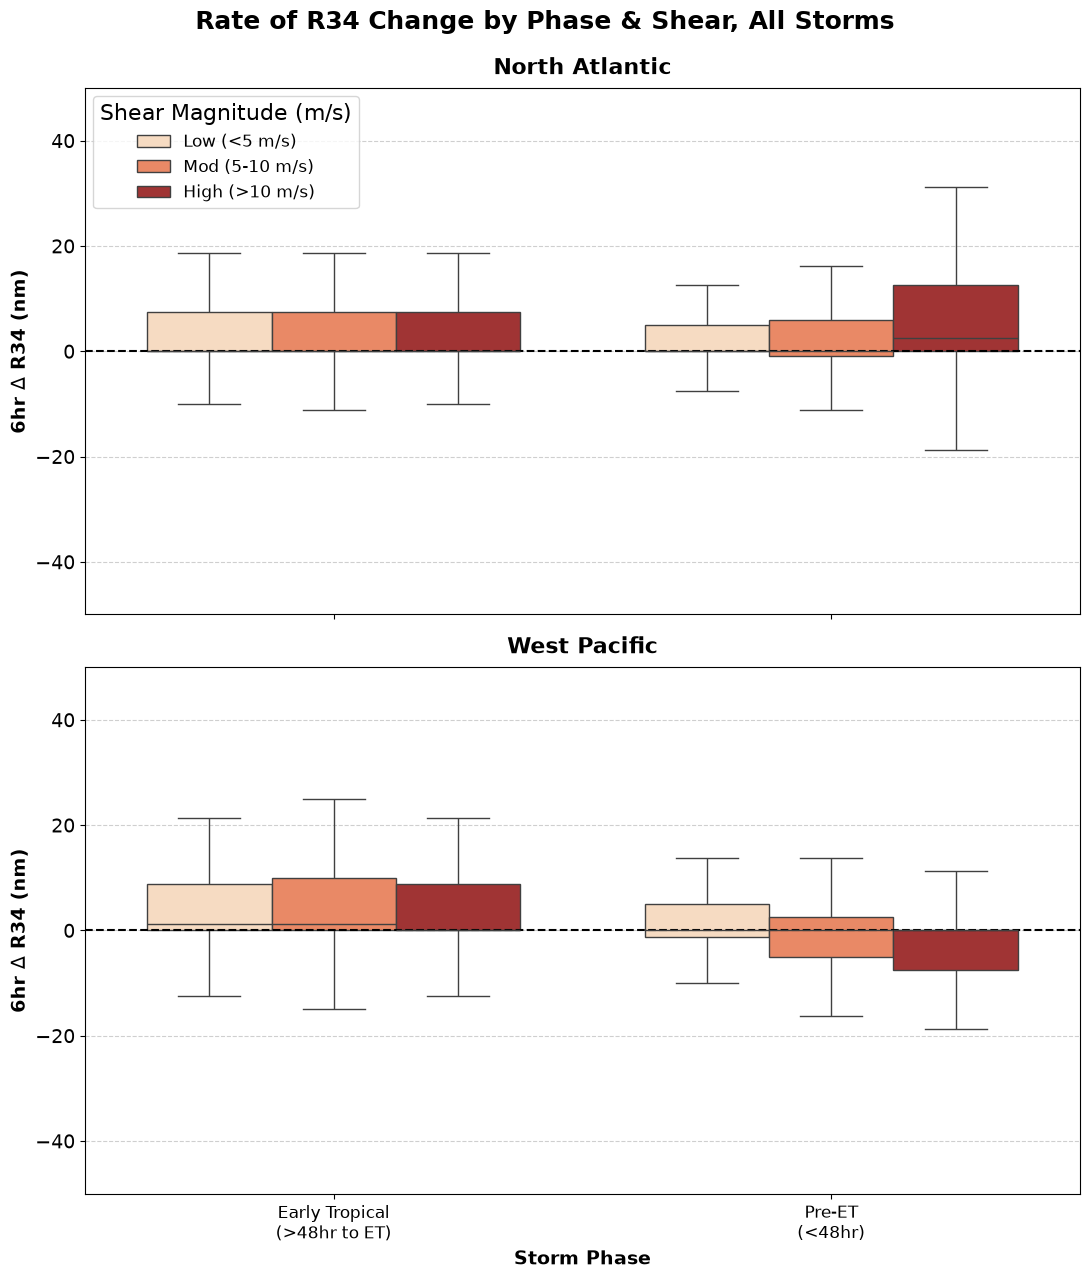

    - Plot saved: COMPOSITE_SHEAR_MS_r34_rate_of_change__All_Storms.png


In [6]:
for exclude_land_interactions in [True, False]:
    analysis_df = master_df.copy()

    if exclude_land_interactions:
        filter_text_for_plots = ", No Land Interaction"
        landfalling_storms = (
            analysis_df[analysis_df["had_landfall"] == True]
            [["basin", "storm_year", "storm_name"]].drop_duplicates()
        )
        analysis_df = analysis_df.merge(
            landfalling_storms, on=["basin", "storm_year", "storm_name"], how="left", indicator=True
        )
        analysis_df = analysis_df[analysis_df["_merge"] == "left_only"].drop(columns=["_merge"])
    else:
        filter_text_for_plots = ", All Storms"

    print(f"\n--- Starting Analysis for: {filter_text_for_plots.strip(', ')} ---")

    for var_name, (col_name, units, diff_periods, y_limits) in VARIABLES.items():
        plot_df, diff_col = compute_rate_of_change_plot_df(
            analysis_df, var_name=var_name, col_name=col_name, diff_periods=diff_periods
        )
        plot_rate_of_change_boxplots_shear_split(
            plot_df, diff_col, var_name, units, filter_text_for_plots, y_limits
        )
